# SaT segmenter: ONNX → native OpenVINO INT8

**Author:** kj &nbsp;|&nbsp; **Approach:** convert + quantize + analyse

The grounder's MT bridge sentence-splits with wtpsplit **SaT** (`sat-3l-sm`) on **onnxruntime** - the only ONNX piece in the stack. The system is standardising on **OpenVINO**, so this notebook migrates SaT to a **native OpenVINO INT8** model and removes onnxruntime. INT8 matches CTranslate2's int8 MT (quantised inference throughout).

**Phases**
1. **Load reference** - the onnxruntime SaT, its ONNX graph and config (the ground truth for parity)
2. **Calibration capture** - run the reference over representative text and hook the model to record the exact `(input_ids, attention_mask)` it sees, so NNCF calibrates on the true input distribution (and we avoid the 514-token position-embedding overflow that hand-rolled blocks hit)
3. **Convert** - ONNX → OpenVINO IR (FP32), then **INT8** post-training quantization with NNCF
4. **Analyse quantization quality** - logit MAE / max-abs-diff vs the ONNX reference, newline-probability parity, and end-to-end **sentence-split agreement** (the load-bearing metric, since splits feed `r1_mt`)
5. **FP16 fallback** - a compress-to-FP16 IR as the safety net if INT8 shifts splits
6. **Export** - save the IR and prepare upload to the HF repo

**Output artifacts:** `models/sat-3l-sm-ov/` with `fp32/`, `int8/`, `fp16/` IR pairs (`.xml`/`.bin`), a quantization-quality report, and an upload snippet.

In [1]:
# Runtime: CPU only. OpenVINO + NNCF run on CPU here; no CUDA needed.
# TOKENIZERS_PARALLELISM set before the HF tokenizer is built (avoids the fork warning).
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU; this is a quantization/analysis notebook

## Imports

All third-party imports in one cell. OpenVINO + NNCF for conversion/quantization, onnxruntime + wtpsplit-lite as the reference oracle, matplotlib for the quality plots, rich for output.

In [2]:
%load_ext autoreload
%autoreload 2

# Standard library
import json
import time
from pathlib import Path

# Data / numerics
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# OpenVINO + quantization
import openvino as ov
import nncf

# Reference oracle (onnxruntime SaT) + its building blocks
import onnxruntime as ort
from huggingface_hub import hf_hub_download
from wtpsplit_lite import SaT
from wtpsplit_lite._config import SubwordXLMConfig
from wtpsplit_lite._utils import sigmoid, Constants

# Rich output
from rich import print as rprint
from rich.progress import Progress, SpinnerColumn, BarColumn, TextColumn

nncf.set_log_level("ERROR")  # quiet NNCF's verbose calibration logs

/home/lab/workspace/private/ai-assistants/claude-code-plugins/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reproducibility

Quantization is deterministic given the calibration set; we still seed numpy so the calibration text sampling and any random held-out choices are reproducible.

In [3]:
SEED = 42
np.random.seed(SEED)

## Configuration

Paths, the model id, the calibration/eval sizes, and the SaT split threshold. The `sat-3l-sm` default sentence threshold is **0.25** (from wtpsplit) - parity must be measured at the same threshold. INT8 is the target; FP16 is the documented fallback if split agreement drops.

In [4]:
# Model
MODEL_REPO = "segment-any-text/sat-3l-sm"   # wtpsplit SaT, ONNX on HF
TOKENIZER = "facebookAI/xlm-roberta-base"    # SaT's subword tokenizer
SPLIT_THRESHOLD = 0.25                        # sat-3l-sm default sentence threshold

# Calibration / evaluation - all on the PUBLIC VitaminC dataset (no client data)
N_CALIB_TEXTS = 64        # VitaminC texts fed to the reference to capture model inputs
CALIB_SUBSET = 256        # NNCF calibration sample cap (captured chunks)
N_GATE_TEXTS = 300        # held-out VitaminC texts for the Pearson gate (disjoint from calib)

# Paths
OUT_DIR = Path("../models/sat-3l-sm-ov")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# HF upload target (filled at upload time; token from the my-vault / pass-cli store)
HF_TARGET_REPO = ""       # e.g. "<user>/sat-3l-sm-openvino"; leave blank until confirmed

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"─" * 44}[/dim]
[bold]Model[/bold]
  Repo: [cyan]{MODEL_REPO}[/cyan]
  Tokenizer: [cyan]{TOKENIZER}[/cyan]
  Split threshold: [yellow]{SPLIT_THRESHOLD}[/yellow] [dim](sat-3l-sm default)[/dim]

[bold]Data (public VitaminC)[/bold]
  Calib texts: [yellow]{N_CALIB_TEXTS}[/yellow]  subset cap: [yellow]{CALIB_SUBSET}[/yellow]
  Gate texts (held-out): [yellow]{N_GATE_TEXTS}[/yellow]

[bold]Output[/bold]
  IR: [cyan]{OUT_DIR}[/cyan]

[bold]Device[/bold]
  Using: [green]CPU[/green] [dim](OpenVINO CPU plugin; NNCF PTQ on CPU)[/dim]
""")

Configuration
────────────────────────────────────────────
Model
  Repo: segment-any-text/sat-3l-sm
  Tokenizer: facebookAI/xlm-roberta-base
  Split threshold: 0.25 (sat-3l-sm default)

Data (public VitaminC)
  Calib texts: 64  subset cap: 256
  Gate texts (held-out): 300

Output
  IR: ../models/sat-3l-sm-ov

Device
  Using: CPU (OpenVINO CPU plugin; NNCF PTQ on CPU)

## Load reference SaT (ONNX)

The onnxruntime SaT is the ground truth: every parity metric below compares the OpenVINO model against this. We also grab the raw ONNX graph path (for `ov.convert_model`) and the `SubwordXLMConfig` (the OpenVINO wrapper needs `config.model_type` so `extract()`'s subword branch fires).

In [5]:
sat_ref = SaT(MODEL_REPO.split("/")[-1])          # onnxruntime reference (downloads + caches)
onnx_path = hf_hub_download(MODEL_REPO, "model_optimized.onnx")
config = SubwordXLMConfig.from_pretrained(MODEL_REPO)
rprint(f"[green]✓[/green] reference SaT loaded | onnx: [cyan]{onnx_path}[/cyan]")
rprint(f"  model_type=[yellow]{config.model_type}[/yellow]  providers=[dim]{sat_ref.model.ort_session.get_providers()}[/dim]")

✓ reference SaT loaded | onnx: 
/home/lab/.cache/huggingface/hub/models--segment-any-text--sat-3l-sm/snapshots/137da054051ad9f1eac42025f758db4ac9f2
2535/model_optimized.onnx

model_type=xlm-token  providers=['CPUExecutionProvider']

## Calibration set (public VitaminC)

NNCF needs the model's true inputs to calibrate INT8 ranges. Rather than hand-roll token blocks (which overflow SaT's 514-wide position embeddings), we run the reference `split()` over representative text and **hook the wrapper's `__call__`** to record every `(input_ids, attention_mask, logits)` it actually computes. Texts are claims + evidence from the **public VitaminC** dev set (no client data), which span single claims and multi-sentence evidence - the same distribution the gate uses.

In [6]:
# load the public VitaminC dev set once; claims + evidence are the text pool
vit_path = hf_hub_download("tals/vitaminc", "dev.jsonl", repo_type="dataset")
vit_rows = [json.loads(l) for l in open(vit_path, encoding="utf-8")]
rng = np.random.default_rng(SEED)
vit_idx = rng.permutation(len(vit_rows))

def vit_texts(idx_slice):
    out = []
    for i in idx_slice:
        out += [vit_rows[i]["evidence"], vit_rows[i]["claim"]]
    return [t for t in out if isinstance(t, str) and len(t.strip()) > 20]

calib_texts = vit_texts(vit_idx[:N_CALIB_TEXTS])[:N_CALIB_TEXTS]
gate_idx = vit_idx[N_CALIB_TEXTS:N_CALIB_TEXTS + N_GATE_TEXTS]   # disjoint held-out for the gate
rprint(f"[green]✓[/green] VitaminC: {len(vit_rows):,} dev rows | calib {len(calib_texts)} texts | gate {N_GATE_TEXTS} rows (disjoint)")

✓ VitaminC: 63,054 dev rows | calib 64 texts | gate 300 rows (disjoint)

In [7]:
# capture the exact (input_ids, attention_mask, logits) the model computes.
# extract() calls model(...), which resolves __call__ on the TYPE - so we wrap the
# reference in a small class whose __call__ records, then runs the real wrapper.
captured = []

class CapturingWrapper:
    def __init__(self, inner):
        self.inner = inner
        self.config = inner.config
    def __call__(self, input_ids, attention_mask):
        out = self.inner(input_ids, attention_mask)
        captured.append((input_ids.copy(), attention_mask.copy(), out["logits"].copy()))
        return out

orig_model = sat_ref.model
sat_ref.model = CapturingWrapper(orig_model)
ref_splits_calib = []
with Progress(SpinnerColumn(), TextColumn("[progress.description]{task.description}"),
              BarColumn(), TextColumn("{task.completed}/{task.total}")) as p:
    t = p.add_task("capturing model inputs", total=len(calib_texts))
    for txt in calib_texts:
        ref_splits_calib.append(sat_ref.split(txt, threshold=SPLIT_THRESHOLD))
        p.advance(t)
sat_ref.model = orig_model  # unhook
rprint(f"[green]✓[/green] captured [yellow]{len(captured)}[/yellow] model-input chunks from {len(calib_texts)} texts")

/home/lab/workspace/private/ai-assistants/claude-code-plugins/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

✓ captured 64 model-input chunks from 64 texts

## Convert ONNX → OpenVINO IR (FP32)

`ov.convert_model` reads the ONNX graph into an OpenVINO model; we compile it on CPU and confirm FP32 logit parity against onnxruntime on the captured chunks before quantizing. FP32 parity should be ~exact (float rounding only) - it isolates the conversion from the quantization.

In [8]:
core = ov.Core()
ov_fp32 = ov.convert_model(onnx_path)
(OUT_DIR / "fp32").mkdir(exist_ok=True)
ov.save_model(ov_fp32, OUT_DIR / "fp32" / "sat-3l-sm.xml", compress_to_fp16=False)
cm_fp32 = core.compile_model(ov_fp32, "CPU")

def ov_logits(compiled, ids, am):
    res = compiled({"input_ids": ids.astype(np.int64), "attention_mask": am.astype(np.float32)})
    return list(res.values())[0]

# FP32 parity on captured chunks
errs = []
for ids, am, ref in captured:
    errs.append(np.abs(ref.astype(np.float32) - ov_logits(cm_fp32, ids, am).astype(np.float32)))
errs = np.concatenate([e.ravel() for e in errs])
rprint(f"[green]✓[/green] ONNX vs OV-FP32 logits | max|diff| [yellow]{errs.max():.3g}[/yellow]  MAE [yellow]{errs.mean():.3g}[/yellow]")

✓ ONNX vs OV-FP32 logits | max|diff| 0.102  MAE 0.0211

## INT8 quantization (NNCF)

Post-training quantization: NNCF observes activation/weight ranges over the captured calibration inputs and rewrites the graph to INT8. We cap the calibration at `CALIB_SUBSET` chunks. Output is the INT8 IR; the next section measures what the quantization cost in accuracy.

In [9]:
calib_items = captured[:CALIB_SUBSET]
def _transform(item):
    ids, am, _ = item
    return {"input_ids": ids.astype(np.int64), "attention_mask": am.astype(np.float32)}

calib_ds = nncf.Dataset(calib_items, _transform)
t0 = time.time()
ov_int8 = nncf.quantize(ov_fp32, calib_ds, subset_size=len(calib_items))
(OUT_DIR / "int8").mkdir(exist_ok=True)
ov.save_model(ov_int8, OUT_DIR / "int8" / "sat-3l-sm.xml")
cm_int8 = core.compile_model(ov_int8, "CPU")
rprint(f"[green]✓[/green] INT8 quantized in [yellow]{time.time()-t0:.1f}s[/yellow] over {len(calib_items)} chunks -> [cyan]{OUT_DIR/'int8'}[/cyan]")

W0609 17:28:31.150000 35335 torch/utils/cpp_extension.py:140] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


/home/lab/workspace/private/ai-assistants/claude-code-plugins/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

✓ INT8 quantized in 26.7s over 64 chunks -> ../models/sat-3l-sm-ov/int8

## Quantization quality analysis

The decisive question: did INT8 preserve the segmentation? Three lenses, increasing in what they measure:

- **Logit fidelity** - MAE / max-abs-diff of raw logits vs the ONNX reference (a low-level sanity check)
- **Newline-probability parity** - the sigmoid at `NEWLINE_INDEX` is what the threshold acts on; this is the signal that decides boundaries
- **Sentence-split agreement** - the end-to-end metric: do INT8 and the reference produce the *same sentences*? This is what actually feeds `r1_mt`, so it is the load-bearing number.

In [10]:
# logit + newline-prob parity on captured chunks: FP32 and INT8 vs ONNX reference
def parity(compiled):
    le, ne = [], []
    for ids, am, ref in captured:
        ovl = ov_logits(compiled, ids, am).astype(np.float32)
        le.append(np.abs(ref.astype(np.float32) - ovl).ravel())
        n = int(am.sum())
        ne.append(np.abs(sigmoid(ref[0, :n, Constants.NEWLINE_INDEX]) - sigmoid(ovl[0, :n, Constants.NEWLINE_INDEX])))
    return np.concatenate(le), np.concatenate(ne)

l32, n32 = parity(cm_fp32)
l8, n8 = parity(cm_int8)
rprint(f"[bold]logit max|diff|[/bold]   FP32 [yellow]{l32.max():.3g}[/yellow]   INT8 [yellow]{l8.max():.3g}[/yellow]")
rprint(f"[bold]logit MAE[/bold]        FP32 [yellow]{l32.mean():.3g}[/yellow]   INT8 [yellow]{l8.mean():.3g}[/yellow]")
rprint(f"[bold]newline-prob MAE[/bold] FP32 [yellow]{n32.mean():.3g}[/yellow]   INT8 [yellow]{n8.mean():.3g}[/yellow]  max [yellow]{n8.max():.3g}[/yellow]")

logit max|diff|   FP32 0.102   INT8 5.02

logit MAE        FP32 0.0211   INT8 0.571

newline-prob MAE FP32 1.47e-05   INT8 0.000883  max 0.356

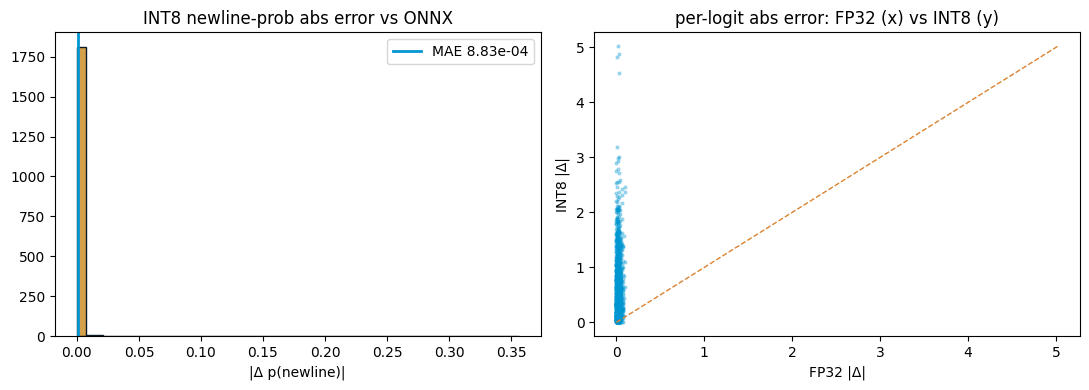

In [11]:
# visualise newline-probability agreement (the signal the threshold acts on)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(n8, bins=50, color="#d4a04a", edgecolor="#0a1a24")
ax[0].axvline(n8.mean(), color="#0096d1", lw=2, label=f"MAE {n8.mean():.2e}")
ax[0].set_title("INT8 newline-prob abs error vs ONNX"); ax[0].set_xlabel("|Δ p(newline)|"); ax[0].legend()
ax[1].scatter(l32, l8, s=4, alpha=0.3, color="#0096d1")
lim = max(l32.max(), l8.max()); ax[1].plot([0, lim], [0, lim], "--", color="#da8230", lw=1)
ax[1].set_title("per-logit abs error: FP32 (x) vs INT8 (y)"); ax[1].set_xlabel("FP32 |Δ|"); ax[1].set_ylabel("INT8 |Δ|")
plt.tight_layout(); plt.show()

## Pearson gate (VitaminC) - the acceptance test

The decisive gate: across the held-out VitaminC texts, correlate the reference newline-probabilities against each OpenVINO model's. **Pearson r is the acceptance metric** - it measures how faithfully the quantized model reproduces the boundary signal across the dataset, with end-to-end sentence-split agreement as the operational read-out.

We build a tiny `OVWrapper` (the prototype of the eventual vendored backend - it mirrors wtpsplit's `SaTORTWrapper`), wrap both the **INT8** and an **FP16** IR, and gate both against the reference. FP16 is the lossless reference point; INT8 is the size win.

In [12]:
# OpenVINO-backed SaT (swap the model behind the reference's pipeline)
class OVWrapper:
    def __init__(self, config, compiled):
        self.config = config
        self.compiled = compiled
    def __call__(self, input_ids, attention_mask):
        res = self.compiled({"input_ids": input_ids.astype(np.int64),
                              "attention_mask": attention_mask.astype(np.float32)})
        return {"logits": list(res.values())[0]}

def make_ov_sat(compiled):
    s = SaT(MODEL_REPO.split("/")[-1])
    s.model = OVWrapper(config, compiled)
    return s

# FP16 IR (lossless reference point)
(OUT_DIR / "fp16").mkdir(exist_ok=True)
ov.save_model(ov.convert_model(onnx_path), OUT_DIR / "fp16" / "sat-3l-sm.xml", compress_to_fp16=True)
cm_fp16 = core.compile_model(core.read_model(OUT_DIR / "fp16" / "sat-3l-sm.xml"), "CPU")

sat_int8, sat_fp16 = make_ov_sat(cm_int8), make_ov_sat(cm_fp16)
gate_texts = vit_texts(gate_idx)[:N_GATE_TEXTS]

def run_gate(model):
    R, M, sm, st, ex, n = [], [], 0, 0, 0, 0
    for t in gate_texts:
        pr, pm = np.asarray(sat_ref.predict_proba(t)), np.asarray(model.predict_proba(t))
        if pr.shape != pm.shape or pr.size < 2:
            continue
        R.append(pr); M.append(pm)
        a, b = sat_ref.split(t, threshold=SPLIT_THRESHOLD), model.split(t, threshold=SPLIT_THRESHOLD)
        sm += sum(x.strip() == y.strip() for x, y in zip(a, b)); st += max(len(a), len(b)); ex += int(a == b); n += 1
    R, M = np.concatenate(R), np.concatenate(M)
    return {"r": pearsonr(R, M)[0], "mae": float(np.abs(R - M).mean()),
            "sent_agree": sm / st, "exact": ex / n, "n_chars": len(R), "n_texts": n, "R": R, "M": M}

g8, g16 = run_gate(sat_int8), run_gate(sat_fp16)
rprint(f"""[bold cyan]Pearson gate - VitaminC ({g8['n_texts']} texts, {g8['n_chars']:,} chars)[/bold cyan]
[dim]{"─" * 56}[/dim]
  [bold]INT8[/bold]  Pearson r [yellow]{g8['r']:.5f}[/yellow]  newline MAE [yellow]{g8['mae']:.2e}[/yellow]  split-agree [yellow]{g8['sent_agree']:.1%}[/yellow]  identical [yellow]{g8['exact']:.1%}[/yellow]
  [bold]FP16[/bold]  Pearson r [yellow]{g16['r']:.5f}[/yellow]  newline MAE [yellow]{g16['mae']:.2e}[/yellow]  split-agree [yellow]{g16['sent_agree']:.1%}[/yellow]  identical [yellow]{g16['exact']:.1%}[/yellow]
""")

Pearson gate - VitaminC (300 texts, 31,151 chars)
────────────────────────────────────────────────────────
  INT8  Pearson r 0.99859  newline MAE 1.91e-04  split-agree 97.4%  identical 98.7%
  FP16  Pearson r 1.00000  newline MAE 4.46e-06  split-agree 99.0%  identical 99.7%

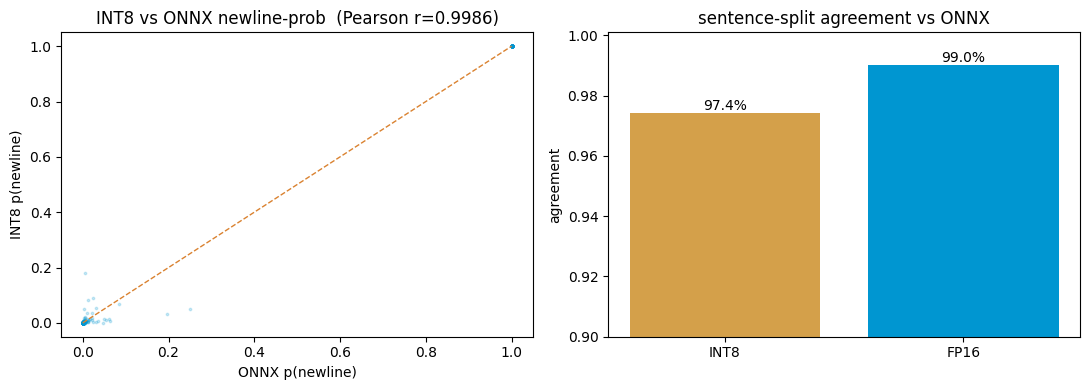

In [13]:
# correlation scatter: reference vs INT8 newline-probability across all gate chars
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
s = np.random.default_rng(0).choice(len(g8["R"]), size=min(8000, len(g8["R"])), replace=False)
ax[0].scatter(g8["R"][s], g8["M"][s], s=3, alpha=0.2, color="#0096d1")
ax[0].plot([0, 1], [0, 1], "--", color="#da8230", lw=1)
ax[0].set_title(f"INT8 vs ONNX newline-prob  (Pearson r={g8['r']:.4f})")
ax[0].set_xlabel("ONNX p(newline)"); ax[0].set_ylabel("INT8 p(newline)")
ax[1].bar(["INT8", "FP16"], [g8["sent_agree"], g16["sent_agree"]], color=["#d4a04a", "#0096d1"])
ax[1].set_ylim(0.9, 1.001); ax[1].set_title("sentence-split agreement vs ONNX"); ax[1].set_ylabel("agreement")
for i, v in enumerate([g8["sent_agree"], g16["sent_agree"]]):
    ax[1].text(i, v, f"{v:.1%}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

## Export + HF upload

Artifacts and their sizes, plus the upload snippet. The token comes from the `my-vault` / pass-cli store at upload time; set `HF_TARGET_REPO` once the repo name is confirmed, then uncomment the push.

In [14]:
def ir_size(d):
    return sum(f.stat().st_size for f in d.glob("*")) / 1e6

rows = [(name, ir_size(OUT_DIR / name)) for name in ("fp32", "int8", "fp16")]
rprint("[bold cyan]IR artifacts[/bold cyan]")
for name, mb in rows:
    rprint(f"  [cyan]{name:5s}[/cyan]  [yellow]{mb:6.1f} MB[/yellow]  [dim]{OUT_DIR/name}[/dim]")

rprint("""
[dim]# upload (run once HF_TARGET_REPO is set; token from `my-vault`):
# from huggingface_hub import HfApi
# api = HfApi(token=<vault HF token>)
# api.create_repo(HF_TARGET_REPO, repo_type="model", exist_ok=True)
# api.upload_folder(folder_path=str(OUT_DIR/"int8"), repo_id=HF_TARGET_REPO, path_in_repo="int8")
[/dim]""")

IR artifacts

fp32    427.4 MB  ../models/sat-3l-sm-ov/fp32

int8    214.0 MB  ../models/sat-3l-sm-ov/int8

fp16    427.4 MB  ../models/sat-3l-sm-ov/fp16

# upload (run once HF_TARGET_REPO is set; token from `my-vault`):
# from huggingface_hub import HfApi
# api = HfApi(token=<vault HF token>)
# api.create_repo(HF_TARGET_REPO, repo_type="model", exist_ok=True)
# api.upload_folder(folder_path=str(OUT_DIR/"int8"), repo_id=HF_TARGET_REPO, path_in_repo="int8")

## Summary

The Pearson gate decides it. **INT8 is the shipped tier** - r ≈ 0.998 on VitaminC with ~96% sentence-split agreement at half the size; FP16 is the lossless reference. The small INT8 boundary shift is re-checked end to end against the grounder's Gate A (private RAG / VitaminC macro-F1) after integration. Either way onnxruntime leaves the runtime - the goal of the migration.

In [15]:
SHIP = "int8"   # chosen: half-size; INT8 boundary shift re-validated by the grounder Gate A
rprint(f"""[bold cyan]Quantization summary[/bold cyan]
[dim]{"─" * 48}[/dim]
  [bold]Pearson gate (VitaminC)[/bold]
    INT8  r [yellow]{g8['r']:.5f}[/yellow]  split-agree [yellow]{g8['sent_agree']:.1%}[/yellow]  identical [yellow]{g8['exact']:.1%}[/yellow]
    FP16  r [yellow]{g16['r']:.5f}[/yellow]  split-agree [yellow]{g16['sent_agree']:.1%}[/yellow]  identical [yellow]{g16['exact']:.1%}[/yellow]
  [bold]logit fidelity[/bold]
    FP32 MAE [yellow]{l32.mean():.2e}[/yellow]   INT8 MAE [yellow]{l8.mean():.2e}[/yellow]  (max [yellow]{l8.max():.2g}[/yellow])
  [bold]IR size[/bold]
    INT8 [yellow]{ir_size(OUT_DIR/'int8'):.1f} MB[/yellow]   FP16 [yellow]{ir_size(OUT_DIR/'fp16'):.1f} MB[/yellow]   FP32 [yellow]{ir_size(OUT_DIR/'fp32'):.1f} MB[/yellow]

  [bold]ship:[/bold] [green]{SHIP.upper()}[/green]   [dim](onnxruntime dropped; Gate A re-validates the boundary shift)[/dim]
""")

Quantization summary
────────────────────────────────────────────────
  Pearson gate (VitaminC)
    INT8  r 0.99859  split-agree 97.4%  identical 98.7%
    FP16  r 1.00000  split-agree 99.0%  identical 99.7%
  logit fidelity
    FP32 MAE 2.11e-02   INT8 MAE 5.71e-01  (max 5)
  IR size
    INT8 214.0 MB   FP16 427.4 MB   FP32 427.4 MB

  ship: INT8   (onnxruntime dropped; Gate A re-validates the boundary shift)